# Deforestation Dataset Analysis - SVM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("deforestation.csv")

In [3]:
df.head()

,Country,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
0,Indonesia,1971,560,8.929641,304,1635.715350,86759840,2551.805035,59.316366,3,9.426264,238,184,7.005531
1,Brazil,1927,3303,4.638441,341,1454.430241,83798502,2637.895996,14.211099,4,2.602618,418,78,20.044415
2,Russia,1961,4466,4.679313,298,1744.809660,41477592,2880.724721,44.869699,2,51.917315,186,49,22.747603
3,Australia,1967,3658,1.535528,285,1541.645853,71475964,2525.516988,10.824516,4,23.716328,190,2,22.701362
4,Australia,1987,2682,8.035841,450,1752.997736,16256333,608.916586,14.577190,4,21.424037,159,41,18.085869


In [4]:
df.isnull().sum()

Country                            0
Year                               0
Forest_Loss_Area_km2               0
Tree_Cover_Loss_percent            0
CO2_Emission_mt                    0
Rainfall_mm                        0
Population                         0
GDP_Billion_USD                    0
Agriculture_Land_Percent           0
Deforestation_Policy_Strictness    0
Corruption_Index                   0
International_Aid_Million_USD      0
Illegal_Lumbering_Incidents        0
Protected_Areas_Percent            0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

Country                                str
Year                                 int64
Forest_Loss_Area_km2                 int64
Tree_Cover_Loss_percent            float64
CO2_Emission_mt                      int64
Rainfall_mm                        float64
Population                           int64
GDP_Billion_USD                    float64
Agriculture_Land_Percent           float64
Deforestation_Policy_Strictness      int64
Corruption_Index                   float64
International_Aid_Million_USD        int64
Illegal_Lumbering_Incidents          int64
Protected_Areas_Percent            float64
dtype: object

In [7]:
df["Country"].unique()

<ArrowStringArray>
['Indonesia', 'Brazil', 'Russia', 'Australia', 'India']
Length: 5, dtype: str

In [8]:
df["Deforestation_Policy_Strictness"].unique()

array([3, 4, 2, 1])

In [9]:
df.min(numeric_only=True)

Year                               1.925000e+03
Forest_Loss_Area_km2               5.030000e+02
Tree_Cover_Loss_percent            1.535528e+00
CO2_Emission_mt                    1.800000e+01
Rainfall_mm                        1.012352e+03
Population                         1.882729e+06
GDP_Billion_USD                    6.669228e+01
Agriculture_Land_Percent           1.073528e+01
Deforestation_Policy_Strictness    1.000000e+00
Corruption_Index                   1.428651e-01
International_Aid_Million_USD      0.000000e+00
Illegal_Lumbering_Incidents        2.000000e+00
Protected_Areas_Percent            5.259525e+00
dtype: float64

In [10]:
df.max(numeric_only=True)

Year                               2.023000e+03
Forest_Loss_Area_km2               4.949000e+03
Tree_Cover_Loss_percent            9.791851e+00
CO2_Emission_mt                    4.840000e+02
Rainfall_mm                        2.984602e+03
Population                         9.783425e+07
GDP_Billion_USD                    4.902381e+03
Agriculture_Land_Percent           5.966608e+01
Deforestation_Policy_Strictness    4.000000e+00
Corruption_Index                   9.949228e+01
International_Aid_Million_USD      4.990000e+02
Illegal_Lumbering_Incidents        1.990000e+02
Protected_Areas_Percent            2.994412e+01
dtype: float64

In [11]:
df.describe()

,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
count,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000
mean,1973.900000,2402.040000,5.581324,249.780000,1989.065675,4.669843e+07,2522.261399,34.699672,2.580000,47.242961,248.17000,101.590000,17.440189
std,30.521561,1289.357713,2.486552,131.947233,580.739902,2.821265e+07,1428.257175,14.939793,1.147505,28.615151,144.81699,60.859516,7.747759
min,1925.000000,503.000000,1.535528,18.000000,1012.352137,1.882729e+06,66.692280,10.735281,1.000000,0.142865,0.00000,2.000000,5.259525
25%,1946.750000,1288.500000,3.409892,142.750000,1519.817401,2.353557e+07,1331.429568,22.341474,2.000000,27.492684,121.25000,55.500000,10.274762
50%,1972.500000,2159.000000,5.540553,257.000000,1875.424360,4.422406e+07,2517.956363,33.265582,3.000000,43.281263,255.00000,95.500000,17.969884
75%,1997.250000,3495.500000,7.642558,358.500000,2543.170733,7.114959e+07,3694.946835,48.173119,4.000000,72.924698,344.50000,159.250000,24.439923
max,2023.000000,4949.000000,9.791851,484.000000,2984.602077,9.783425e+07,4902.380882,59.666082,4.000000,99.492284,499.00000,199.000000,29.944121


In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

ss = StandardScaler()
le = LabelEncoder()

In [13]:
df["Deforestation_Policy_Strictness"] = le.fit_transform(df["Deforestation_Policy_Strictness"])

In [14]:
df["Deforestation_Policy_Strictness"].head(20)

0     2
1     3
2     1
3     3
4     3
5     3
6     0
7     3
8     1
9     0
10    0
11    1
12    2
13    0
14    3
15    1
16    2
17    2
18    3
19    3
Name: Deforestation_Policy_Strictness, dtype: int64

In [15]:
df["Corruption_Index"] = le.fit_transform(df["Corruption_Index"])

In [16]:
df['Corruption_Index'].head(20)

0     12
1      3
2     62
3     22
4     19
5     92
6     48
7     13
8     11
9     71
10    49
11    78
12    34
13     4
14    53
15    85
16    51
17    82
18    83
19    96
Name: Corruption_Index, dtype: int64

In [17]:
num_col = [
    "CO2_Emission_mt",
    "Population",
    "GDP_Billion_USD"
]

In [18]:
df[num_col] = ss.fit_transform(df[num_col])

In [19]:
df.head()

,Country,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
0,Indonesia,1971,560,8.929641,0.412992,1635.715350,1.427134,0.020789,59.316366,2,12,238,184,7.005531
1,Brazil,1927,3303,4.638441,0.694820,1454.430241,1.321640,0.081370,14.211099,3,3,418,78,20.044415
2,Russia,1961,4466,4.679313,0.367290,1744.809660,-0.185985,0.252244,44.869699,1,62,186,49,22.747603
3,Australia,1967,3658,1.535528,0.268270,1541.645853,0.882666,0.002291,10.824516,3,22,190,2,22.701362
4,Australia,1987,2682,8.035841,1.525069,1752.997736,-1.084459,-1.346385,14.577190,3,19,159,41,18.085869


In [20]:
print("\nMean after standardization:")
print(df[num_col].mean())


print("\nStandard deviation after standardization:") 
print(df[num_col].std())


Mean after standardization:
CO2_Emission_mt    0.000000e+00
Population        -4.871104e-17
GDP_Billion_USD    3.624878e-16
dtype: float64

Standard deviation after standardization:
CO2_Emission_mt    1.005038
Population         1.005038
GDP_Billion_USD    1.005038
dtype: float64


In [21]:
from sklearn.model_selection import train_test_split 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
X = df.drop(["Forest_Loss_Area_km2","Tree_Cover_Loss_percent"], axis=1) 
y = df["Forest_Loss_Area_km2"]

In [23]:
cat_col = ["Country"]

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

In [24]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [25]:
X_train.shape

(80, 12)

In [26]:
X_test.shape

(20, 12)

In [27]:
y_train.shape

(80,)

In [28]:
y_test.shape

(20,)

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_col),
        ("cat", OneHotEncoder(), cat_col)
    ]
)

In [30]:
svm_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("svm", SVR(kernel="linear"))
    ]
)

In [31]:
svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Country','Year','CO2_Emission_mt',...,'International_Aid_Million_USD', 'Illegal_Lumbering_Incidents','Protected_Areas_Percent']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will

In [32]:
train_pred = svm_model.predict(X_train)

In [33]:
mae = mean_absolute_error(y_train, train_pred)
mse = mean_squared_error(y_train, train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, train_pred)

In [34]:
print("Linear SVM Model Performance on Training Data") 
print("MAE:", mae) 
print("MSE:", mse) 
print("RMSE:", rmse) 
print("R-squared:", r2)

Linear SVM Model Performance on Training Data
MAE: 1138.1941382609766
MSE: 1699154.995008165
RMSE: 1303.516396140902
R-squared: -0.007297254784349727


In [35]:
test_pred = svm_model.predict(X_test)

In [36]:
test_mae = mean_absolute_error(y_test, test_pred)
test_mse = mean_squared_error(y_test, test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, test_pred)

In [37]:
print("\nLinear SVM Model Performance on Test Data") 
print("MAE:", test_mae) 
print("MSE:", test_mse) 
print("RMSE:", test_rmse) 
print("R-squared:", test_r2)


Linear SVM Model Performance on Test Data
MAE: 1017.5095871432553
MSE: 1411386.106533866
RMSE: 1188.0177214729863
R-squared: -0.31999599876025964


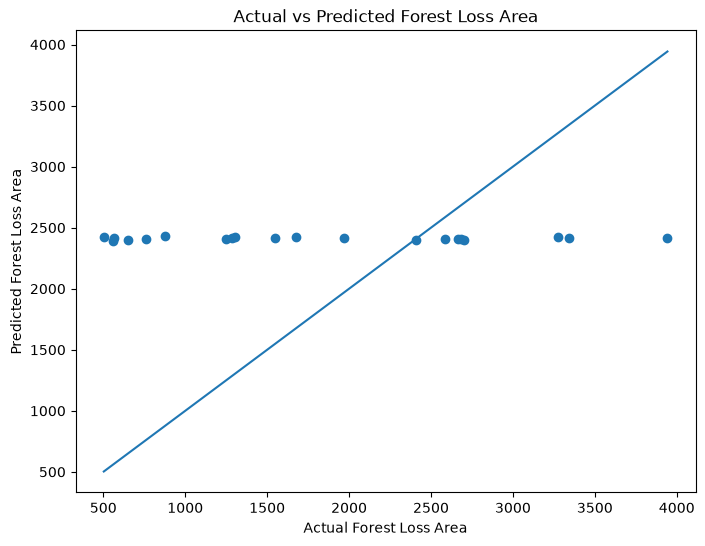

In [38]:
plt.figure(figsize=(8, 6)) 
plt.scatter(y_test, test_pred)
plt.xlabel("Actual Forest Loss Area") 
plt.ylabel("Predicted Forest Loss Area") 
plt.title("Actual vs Predicted Forest Loss Area")
plt.plot( [y_test.min(), y_test.max()], [y_test.min(), y_test.max()] ) 
plt.show()

In [39]:
from sklearn.model_selection import GridSearchCV

In [40]:
svm_hyper_model = Pipeline([
    ("preprocessor", preprocessor),
    ("svm", SVR())
])

In [41]:
parameters = { 
    "svm__kernel": ["linear", "poly", "rbf"], 
    "svm__C": [0.1, 1, 10, 100], 
    "svm__gamma": ["scale", "auto"], 
    "svm__degree": [2, 3] 
}

In [42]:
grid_search = GridSearchCV(
    svm_hyper_model, 
    parameters, 
    cv=5, 
    scoring="neg_mean_squared_error" 
)

In [43]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVR())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.1, 1, ...], 'svm__degree': [2, 3], 'svm__gamma': ['scale', 'auto'], 'svm__kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable

In [44]:
print("Best Parameters:") 
print(grid_search.best_params_)

Best Parameters:
{'svm__C': 10, 'svm__degree': 2, 'svm__gamma': 'scale', 'svm__kernel': 'poly'}


In [45]:
best_model = grid_search.best_estimator_
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Country','Year','CO2_Emission_mt',...,'International_Aid_Million_USD', 'Illegal_Lumbering_Incidents','Protected_Areas_Percent']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will

In [46]:
best_prediction = best_model.predict(X_test)

In [47]:
hyper_mae = mean_absolute_error(y_test, best_prediction) 
hyper_mse = mean_squared_error(y_test, best_prediction) 
hyper_rmse = np.sqrt(mse) 
hyper_r2 = r2_score(y_test, best_prediction) 

In [48]:
print("MAE:", hyper_mae) 
print("MSE:", hyper_mse) 
print("RMSE:", hyper_rmse) 
print("R-squared:", hyper_r2)

MAE: 1007.7457709464421
MSE: 1383618.9298118656
RMSE: 1303.516396140902
R-squared: -0.2940268029461375


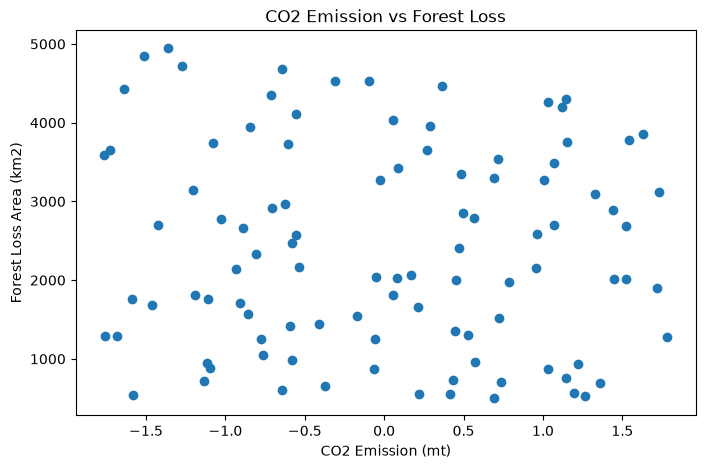

In [49]:
plt.figure(figsize=(8, 5)) 
plt.scatter( x=df["CO2_Emission_mt"], y=df["Forest_Loss_Area_km2"]) 
plt.xlabel("CO2 Emission (mt)") 
plt.ylabel("Forest Loss Area (km2)") 
plt.title("CO2 Emission vs Forest Loss") 
plt.show()

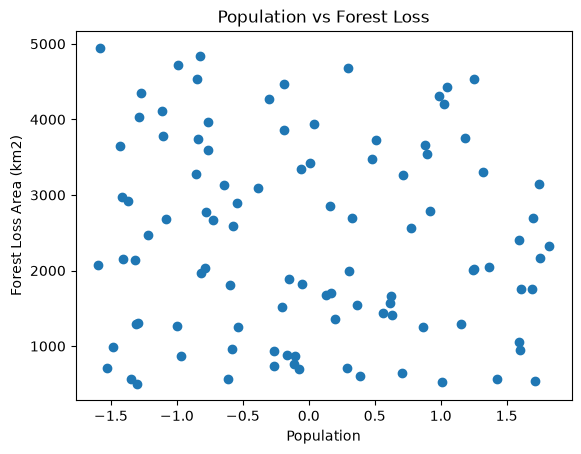

In [50]:
plt.scatter( df["Population"], df["Forest_Loss_Area_km2"] ) 
plt.xlabel("Population") 
plt.ylabel("Forest Loss Area (km2)") 
plt.title("Population vs Forest Loss") 
plt.show()

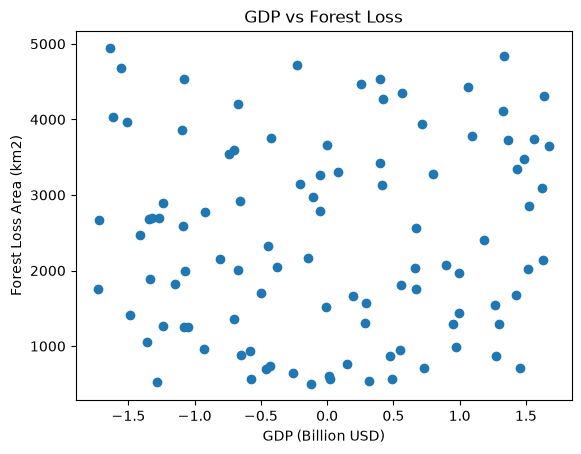

In [51]:
plt.scatter( df["GDP_Billion_USD"], df["Forest_Loss_Area_km2"] ) 
plt.xlabel("GDP (Billion USD)") 
plt.ylabel("Forest Loss Area (km2)") 
plt.title("GDP vs Forest Loss") 
plt.show()

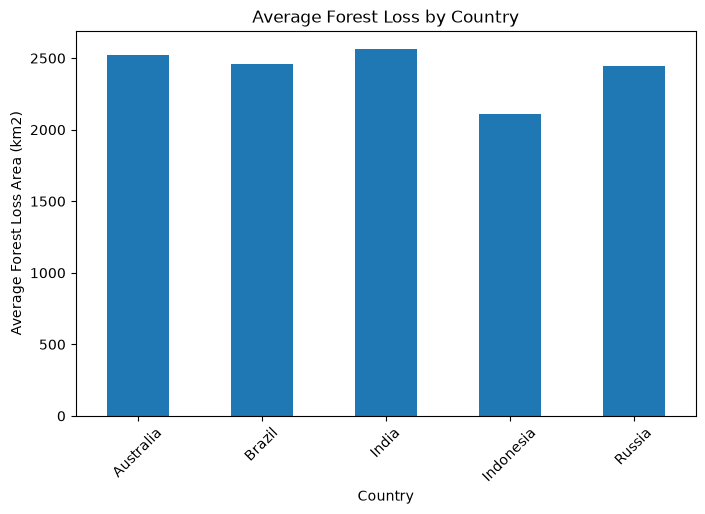

In [52]:
country_loss = df.groupby("Country")["Forest_Loss_Area_km2"].mean() 
plt.figure(figsize=(8, 5)) 
country_loss.plot(kind="bar") 
plt.xlabel("Country") 
plt.ylabel("Average Forest Loss Area (km2)") 
plt.title("Average Forest Loss by Country") 
plt.xticks(rotation=45) 
plt.show()

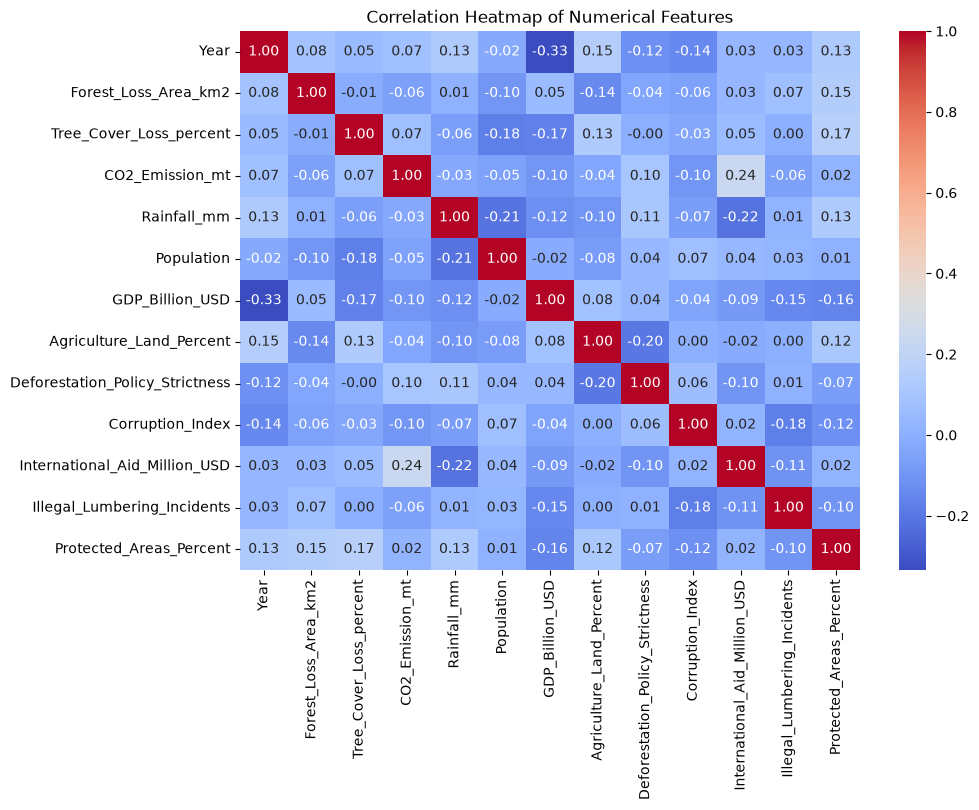

In [53]:
plt.figure(figsize=(10, 7)) 
correlation = df.select_dtypes(include="number").corr() 
sns.heatmap( correlation, annot=True, cmap="coolwarm", fmt=".2f" ) 
plt.title("Correlation Heatmap of Numerical Features") 
plt.show()

In [55]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [56]:
data = df.copy()

In [57]:
data['Forest_Loss'] = pd.qcut(
    data['Forest_Loss_Area_km2'], 2,
    labels=['Low_Forest_Loss', 'High_Forest_Loss']
)

data['Tree_Cover_Loss'] = pd.qcut(
    data['Tree_Cover_Loss_percent'], 2,
    labels=['Low_Tree_Cover_Loss', 'High_Tree_Cover_Loss']
)

data['CO2_Emission'] = pd.qcut(
    data['CO2_Emission_mt'], 2,
    labels=['Low_CO2', 'High_CO2']
)

data['Agriculture_Land'] = pd.qcut(
    data['Agriculture_Land_Percent'], 2,
    labels=['Low_Agriculture', 'High_Agriculture']
)

data['Policy_Strictness'] = pd.qcut(
    data['Deforestation_Policy_Strictness'], 2,
    labels=['Low_Policy_Strictness', 'High_Policy_Strictness']
)

data['Illegal_Lumbering'] = pd.qcut(
    data['Illegal_Lumbering_Incidents'], 2,
    labels=['Low_Illegal_Lumbering', 'High_Illegal_Lumbering']
)

data['Protected_Areas'] = pd.qcut(
    data['Protected_Areas_Percent'], 2,
    labels=['Low_Protected_Areas', 'High_Protected_Areas']
)


In [58]:
data.head()

,Country,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,...,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent,Forest_Loss,Tree_Cover_Loss,CO2_Emission,Agriculture_Land,Policy_Strictness,Illegal_Lumbering,Protected_Areas
0,Indonesia,1971,560,8.929641,0.412992,1635.715350,1.427134,0.020789,59.316366,2,...,238,184,7.005531,Low_Forest_Loss,High_Tree_Cover_Loss,High_CO2,High_Agriculture,Low_Policy_Strictness,High_Illegal_Lumbering,Low_Protected_Areas
1,Brazil,1927,3303,4.638441,0.694820,1454.430241,1.321640,0.081370,14.211099,3,...,418,78,20.044415,High_Forest_Loss,Low_Tree_Cover_Loss,High_CO2,Low_Agriculture,High_Policy_Strictness,Low_Illegal_Lumbering,High_Protected_Areas
2,Russia,1961,4466,4.679313,0.367290,1744.809660,-0.185985,0.252244,44.869699,1,...,186,49,22.747603,High_Forest_Loss,Low_Tree_Cover_Loss,High_CO2,High_Agriculture,Low_Policy_Strictness,Low_Illegal_Lumbering,High_Protected_Areas
3,Australia,1967,3658,1.535528,0.268270,1541.645853,0.882666,0.002291,10.824516,3,...,190,2,22.701362,High_Forest_Loss,Low_Tree_Cover_Loss,High_CO2,Low_Agriculture,High_Policy_Strictness,Low_Illegal_Lumbering,High_Protected_Areas
4,Australia,1987,2682,8.035841,1.525069,1752.997736,-1.084459,-1.346385,14.577190,3,...,159,41,18.085869,High_Forest_Loss,High_Tree_Cover_Loss,High_CO2,Low_Agriculture,High_Policy_Strictness,Low_Illegal_Lumbering,High_Protected_Areas


In [59]:
transactions = data[
    [
        'Country',
        'Forest_Loss',
        'Tree_Cover_Loss',
        'CO2_Emission',
        'Agriculture_Land',
        'Policy_Strictness',
        'Illegal_Lumbering',
        'Protected_Areas'
    ]
]

In [60]:
transaction_list = transactions.astype(str).values.tolist()

In [61]:
te = TransactionEncoder()
te_array = te.fit(transaction_list).transform(transaction_list)

In [62]:
transaction_df = pd.DataFrame(
    te_array,
    columns=te.columns_
)

In [63]:
frequent = apriori(
    transaction_df,
    min_support=0.10,
    use_colnames=True
)

In [65]:
print("Frequent Itemsets\n",frequent)

Frequent Itemsets
      support                                           itemsets
0       0.15                             frozenset({Australia})
1       0.23                                frozenset({Brazil})
2       0.50                      frozenset({High_Agriculture})
3       0.49                              frozenset({High_CO2})
4       0.50                      frozenset({High_Forest_Loss})
..       ...                                                ...
440     0.11  frozenset({Low_Illegal_Lumbering, Low_CO2, Low...
441     0.12  frozenset({Low_Policy_Strictness, Low_CO2, Low...
442     0.11  frozenset({Low_Illegal_Lumbering, Low_Forest_L...
443     0.11  frozenset({Low_Illegal_Lumbering, Low_Tree_Cov...
444     0.10  frozenset({Low_Policy_Strictness, Low_CO2, Hig...

[445 rows x 2 columns]


In [66]:
rules = association_rules(
    frequent,
    metric='confidence',
    min_threshold=0.50
)

In [68]:
rules = rules[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift']
]

print("\nAssociation Rules:")
rules.sort_values(
    by='lift',
    ascending=False
)


Association Rules:


,antecedents,consequents,support,confidence,lift
904,"frozenset({Low_Policy_Strictness, Low_CO2, Low...","frozenset({High_Agriculture, Low_Protected_Are...",0.10,0.588235,2.557545
627,"frozenset({Low_CO2, Low_Forest_Loss})","frozenset({High_Agriculture, Low_Protected_Are...",0.13,0.520000,2.260870
626,"frozenset({High_Agriculture, Low_Protected_Are...","frozenset({Low_CO2, Low_Forest_Loss})",0.13,0.565217,2.260870
732,"frozenset({High_Forest_Loss, Low_Protected_Are...","frozenset({High_Illegal_Lumbering, Low_Agricul...",0.13,0.590909,2.188552
903,"frozenset({Low_Policy_Strictness, High_Agricul...","frozenset({Low_CO2, Low_Forest_Loss})",0.10,0.526316,2.105263
...,...,...,...,...,...
8,frozenset({Brazil}),frozenset({Low_Policy_Strictness}),0.13,0.565217,0.807453
429,"frozenset({High_Protected_Areas, Low_Agricultu...",frozenset({Low_Policy_Strictness}),0.13,0.565217,0.807453
797,"frozenset({Low_Tree_Cover_Loss, High_Forest_Lo...",frozenset({Low_Policy_Strictness}),0.10,0.526316,0.751880
488,"frozenset({Low_Tree_Cover_Loss, Low_Agriculture})",frozenset({Low_Policy_Strictness}),0.14,0.518519,0.740741


In [69]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [70]:
cv_results = []

In [75]:
for fold, (train_idx, val_idx) in enumerate(
    kf.split(transaction_list), start=1
):
    train_transactions = [
        transaction_list[i] for i in train_idx
    ]

    validation_transactions = [
        transaction_list[i] for i in val_idx
    ]

    encoder = TransactionEncoder()

    train_array = encoder.fit(
        train_transactions,
    ).transform(train_transactions)

    train_df = pd.DataFrame(
        train_array,
        columns=encoder.columns_
    )

    itemsets = apriori(
        train_df,
        min_support=0.10,
        use_colnames=True
    )

    rules = association_rules(
        itemsets,
        metric="confidence",
        min_threshold=0.50
    )

    validation_sets = [
        set(transaction)
        for transaction in validation_transactions
    ]

    for _, rule in rules.iterrows():
        antecedent = set(rule["antecedents"])
        consequent = set(rule["consequents"])

        antecedent_count = sum(
            antecedent.issubset(transaction)
            for transaction in validation_sets
        )
        consequent_count = sum(
            consequent.issubset(transaction)
            for transaction in validation_sets
        )
        both_count = sum(
            antecedent.union(consequent).issubset(transaction)
            for transaction in validation_sets
        )

        support = both_count / len(validation_sets)

        if antecedent_count > 0:
            confidence = both_count / antecedent_count
        else:
            confidence = 0

        consequent_support = consequent_count / len(validation_sets)

        if consequent_support > 0:
            lift = confidence / consequent_support
        else:
            lift = 0

        cv_results.append({
            "fold": fold,
            "antecedents": rule["antecedents"],
            "consequents": rule["consequents"],
            "support": support,
            "confidence": confidence,
            "lift": lift
        })

In [82]:
cv_rules = pd.DataFrame(cv_results)

In [83]:
cv_summary = (
    cv_rules.groupby(
        [
            "antecedents", "consequents"
        ]
    )[
        ["support", "confidence", "lift"]
    ].agg(
        ["mean", "std"]
    ).sort_values(
        ("lift", "mean"),
        ascending=False
    )
)

In [84]:
cv_summary.head(10)

support  \
                                                                                                           mean   
antecedents                                        consequents                                                    
frozenset({High_Forest_Loss, Low_Protected_Areas}) frozenset({High_Illegal_Lumbering, High_CO2})       0.025000   
frozenset({High_Forest_Loss, High_Tree_Cover_Lo... frozenset({High_Protected_Areas, Low_CO2})          0.025000   
frozenset({Low_Illegal_Lumbering, High_Forest_L... frozenset({High_Protected_Areas, High_CO2})         0.025000   
frozenset({High_Tree_Cover_Loss, Low_Protected_... frozenset({Low_Policy_Strictness, High_CO2})        0.058333   
frozenset({Low_Policy_Strictness, High_Protecte... frozenset({High_Tree_Cover_Loss})                   0.043750   
frozenset({High_Protected_Areas, Brazil})          frozenset({Low_Tree_Cover_Loss})                    0.025000   
frozenset({Low_Illegal_Lumbering, Low_CO2})        frozenset({Low_Tree_Cover_Loss, Low_Protected_A...  0.050000   
frozenset({High_Forest_Loss, Low_Protected_Areas}) frozenset({High_Illegal_Lumbering, Low_Agricult...  0.043750   
frozenset({High_Policy_Strictness, Low_Agricult... frozenset({High_CO2})                               0.060000   
frozenset({Indonesia, Low_Protected_Areas})        frozenset({High_CO2})                               0.025000   

                                                                                                                 \
                                                                                                            std   
antecedents                                        consequents                                                    
frozenset({High_Forest_Loss, Low_Protected_Areas}) frozenset({High_Illegal_Lumbering, High_CO2})       0.035355   
frozenset({High_Forest_Loss, High_Tree_Cover_Lo... frozenset({High_Protected_Areas, Low_CO2})          0.035355   
frozenset({Low_Illegal_Lumbering, High_Forest_L... frozenset({High_Protected_Areas, High_CO2})         0.035355   
frozenset({High_Tree_Cover_Loss, Low_Protected_... frozenset({Low_Policy_Strictness, High_CO2})        0.066458   
frozenset({Low_Policy_Strictness, High_Protecte... frozenset({High_Tree_Cover_Loss})                   0.049552   
frozenset({High_Protected_Areas, Brazil})          frozenset({Low_Tree_Cover_Loss})                    0.035355   
frozenset({Low_Illegal_Lumbering, Low_CO2})        frozenset({Low_Tree_Cover_Loss, Low_Protected_A...  0.070711   
frozenset({High_Forest_Loss, Low_Protected_Areas}) frozenset({High_Illegal_Lumbering, Low_Agricult...  0.056300   
frozenset({High_Policy_Strictness, Low_Agricult... frozenset({High_CO2})                               0.087560   
frozenset({Indonesia, Low_Protected_Areas})        frozenset({High_CO2})                               0.028868   

                                                                                                      confidence  \
                                                                                                            mean   
antecedents                                        consequents                                                     
frozenset({High_Forest_Loss, Low_Protected_Areas}) frozenset({High_Illegal_Lumbering, High_CO2})        0.100000   
frozenset({High_Forest_Loss, High_Tree_Cover_Lo... frozenset({High_Protected_Areas, Low_CO2})           0.100000   
frozenset({Low_Illegal_Lumbering, High_Forest_L... frozenset({High_Protected_Areas, High_CO2})          0.071429   
frozenset({High_Tree_Cover_Loss, Low_Protected_... frozenset({Low_Policy_Strictness, High_CO2})         0.204762   
frozenset({Low_Policy_Strictness, High_Protecte... frozenset({High_Tree_Cover_Loss})                    0.458333   
frozenset({High_Protected_Areas, Brazil})          frozenset({Low_Tree_Cover_Loss})                     0.500000   
frozenset({Low_Illegal_Lumbering, Low_CO2})        frozenset({Low_Tr

In [ ]:
data['Pollution_Severity'] = pd.qcut(
    data['CO2_Emission_mt'],
    q=3,
    labels=['Low_Pollution', 'Medium_Pollution', 'High_Pollution']
 )
data[['CO2_Emission_mt', 'Pollution_Severity']].head()

,CO2_Emission_mt,Pollution_Severity
0,0.412992,Medium_Pollution
1,0.694820,High_Pollution
2,0.367290,Medium_Pollution
3,0.268270,Medium_Pollution
4,1.525069,High_Pollution


In [ ]:
raw_scaled_values = ss.inverse_transform(data[num_col])
raw_values = pd.DataFrame(
    raw_scaled_values,
    columns=num_col,
    index=data.index
 )
data['Energy_Consumption_Index'] = (
    raw_values['CO2_Emission_mt']
    / raw_values['GDP_Billion_USD'].clip(lower=0.001)
 )
data[['CO2_Emission_mt', 'GDP_Billion_USD', 'Energy_Consumption_Index']].head()

,CO2_Emission_mt,GDP_Billion_USD,Energy_Consumption_Index
0,0.412992,0.020789,0.119131
1,0.694820,0.081370,0.129270
2,0.367290,0.252244,0.103446
3,0.268270,0.002291,0.112848
4,1.525069,-1.346385,0.739017


In [ ]:
encoded_data = data.copy()
categorical_columns = encoded_data.select_dtypes(
    include=['object', 'category', 'string']
 ).columns
label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    encoded_data[column] = encoder.fit_transform(
        encoded_data[column].astype(str)
    )
    label_encoders[column] = encoder

encoded_data[categorical_columns].head()

,Country,Forest_Loss,Tree_Cover_Loss,CO2_Emission,Agriculture_Land,Policy_Strictness,Illegal_Lumbering,Protected_Areas,Pollution_Severity
0,3,1,0,0,0,1,0,1,2
1,1,0,1,0,1,0,1,0,0
2,4,0,1,0,0,1,1,0,2
3,0,0,1,0,1,0,1,0,2
4,0,0,0,0,1,0,1,0,0


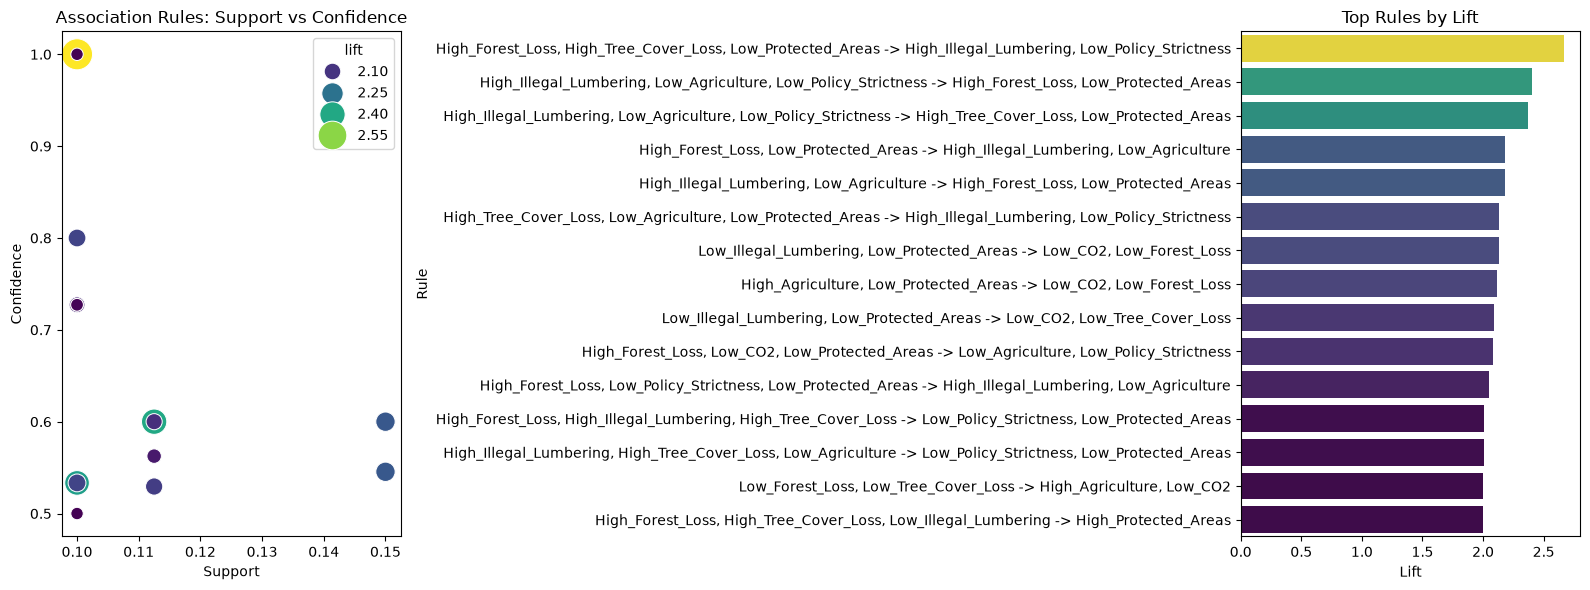

In [ ]:
plot_rules = rules.copy()
plot_rules['antecedents'] = plot_rules['antecedents'].apply(
    lambda items: ', '.join(sorted(items))
 )
plot_rules['consequents'] = plot_rules['consequents'].apply(
    lambda items: ', '.join(sorted(items))
 )
plot_rules['rule'] = (
    plot_rules['antecedents'] + ' -> ' + plot_rules['consequents']
 )
plot_rules = plot_rules.sort_values('lift', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    data=plot_rules,
    x='support',
    y='confidence',
    size='lift',
    hue='lift',
    palette='viridis',
    sizes=(80, 500),
    ax=axes[0]
 )
axes[0].set_title('Association Rules: Support vs Confidence')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')

sns.barplot(
    data=plot_rules,
    y='rule',
    x='lift',
    hue='lift',
    palette='viridis',
    legend=False,
    ax=axes[1]
 )
axes[1].set_title('Top Rules by Lift')
axes[1].set_xlabel('Lift')
axes[1].set_ylabel('Rule')
plt.tight_layout()
plt.show()